## Import dependancies

In [16]:
import sys
import joblib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sys.path.insert(0, "..")
from flood.risk_levels import score_to_risk_level

## Load data 

In [2]:
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/flood_dataset.csv")
df["risk_level"] = df["flood_risk_score"].apply(score_to_risk_level)

## prepare labels

In [4]:
feature_cols = ["rainfall_7d_mm",
    "monthly_rainfall_mm",
    "elevation_m",
    "distance_to_river_m",
    "drainage_index",
    "historical_flood_count"
]

target = "risk_level"

df = df.dropna(subset=feature_cols + [target])

## Print feature columns and taget column

In [6]:
print(f"Training on {len(df):,} rows, {len(feature_cols)} features")

Training on 25,000 rows, 6 features


In [7]:
df[feature_cols + [target]].head()

,rainfall_7d_mm,monthly_rainfall_mm,elevation_m,distance_to_river_m,drainage_index,historical_flood_count,risk_level
0,140.8,107.1,88,339.2,0.350,0,low
1,126.6,177.6,58,1257.6,0.360,0,low
2,155.1,242.2,80,5225.3,0.728,0,low
3,10.1,171.6,111,2950.4,0.288,0,low
4,36.1,436.5,26,228.3,0.435,1,high


## Split data into train and test

In [10]:
label_encoder = LabelEncoder()

X = df[feature_cols]
y = label_encoder.fit_transform(df[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} rows \nTest: {X_test.shape[0]:,} rows")
print("Classes:", list(label_encoder.classes_))

Train: 20,000 rows 
Test: 5,000 rows
Classes: ['high', 'low', 'medium']


## Build and compare models

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier( n_estimators=300, max_depth=10, min_samples_leaf=3, random_state=42, class_weight="balanced", n_jobs=-1)
}

results = {}

for name, classifier in models.items():
    classifier.fit(X_train, y_train)
    acc = accuracy_score(y_test, classifier.predict(X_test))
    results[name] = acc
    print(f"{name:22s} accuracy = {acc:.3f}")

c:\Projects\original capstone project\SLFloodWatch\env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression    accuracy = 0.831
Decision Tree          accuracy = 0.883
Random Forest          accuracy = 0.921


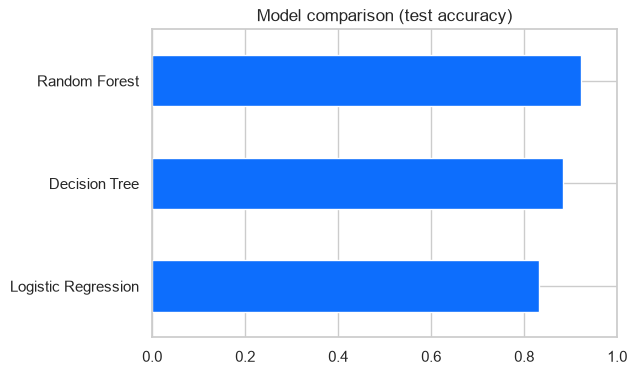

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
pd.Series(results).sort_values().plot(kind="barh", ax=ax, color="#0d6efd")
ax.set_xlim(0, 1)
ax.set_title("Model comparison (test accuracy)")
plt.show()

Random Forest has more accuracy compare to the other models. It can capture the non-linear way rainfall,
elevation, and drainage interact, which a linear model (Logistic
Regression) can't. We'll take Random Forest forward as the final model,
matching what `prediction/ml_model.py` trains for the live app.

## Classification Report of Random Forest Model

In [13]:
model = models["Random Forest"] 

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.3f}\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

Test accuracy: 0.921

              precision    recall  f1-score   support

        high       0.80      0.88      0.84       222
         low       0.98      0.92      0.95      3439
      medium       0.81      0.93      0.86      1339

    accuracy                           0.92      5000
   macro avg       0.86      0.91      0.88      5000
weighted avg       0.93      0.92      0.92      5000



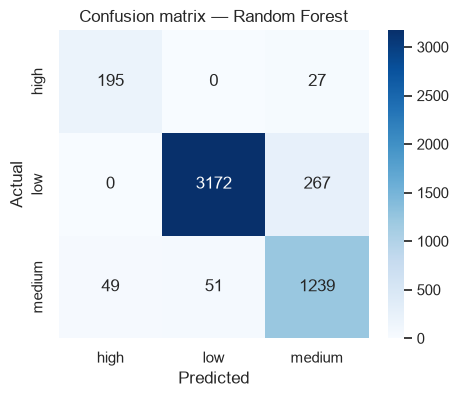

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — Random Forest")
plt.show()

## feature importance

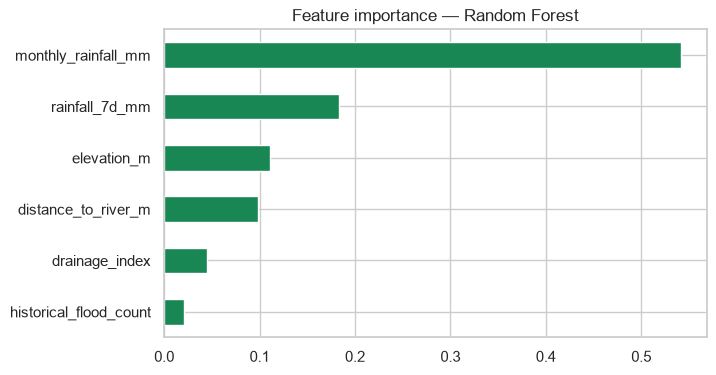

monthly_rainfall_mm       0.541504
rainfall_7d_mm            0.182981
elevation_m               0.111106
distance_to_river_m       0.098537
drainage_index            0.044749
historical_flood_count    0.021123
dtype: float64

In [15]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="#198754")
ax.set_title("Feature importance — Random Forest")
plt.show()

importances.sort_values(ascending=False)

## Save the model for the Django app

In [17]:
MODEL_PATH = "../ml_models/flood_model.pkl"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

joblib.dump({"model": model, "label_encoder": label_encoder}, MODEL_PATH)
print(f"Saved model + label encoder to {MODEL_PATH}")
print("This is the exact bundle format prediction/ml_model.py loads at request time.")

Saved model + label encoder to ../ml_models/flood_model.pkl
This is the exact bundle format prediction/ml_model.py loads at request time.


Quick sanity check: reload from disk and run one prediction, the same way prediction/ml_model.py's predict_risk() does internally.

In [18]:
bundle = joblib.load(MODEL_PATH)
loaded_model, loaded_encoder = bundle["model"], bundle["label_encoder"]

sample = pd.DataFrame([{
    "rainfall_7d_mm": 120.0,
    "monthly_rainfall_mm": 480.0,
    "elevation_m": 15,
    "distance_to_river_m": 80,
    "drainage_index": 0.25,
    "historical_flood_count": 3,
}])[feature_cols]

pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]
print("Predicted risk level:", loaded_encoder.inverse_transform([pred])[0])
print("Class probabilities:", dict(zip(loaded_encoder.classes_, proba.round(3))))

Predicted risk level: high
Class probabilities: {'high': np.float64(0.988), 'low': np.float64(0.001), 'medium': np.float64(0.012)}
